In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# For better display
plt.rcParams['figure.figsize'] = (6,4)

(np.float64(-0.5), np.float64(764.5), np.float64(768.5), np.float64(-0.5))

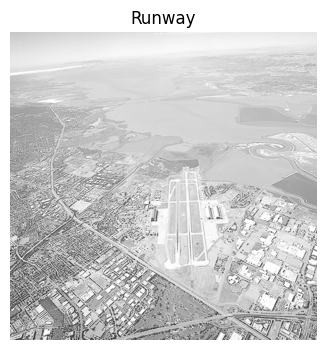

In [ ]:
runway = cv2.imread('images/runway.png', 0)
highlights_and_shadows = cv2.imread('images/highlights_and_shadows.jpg')
# noise = cv2.imread('images/noise.png', 0)
# color_img = cv2.imread('images/gamma.png', 0)

# Show sample
plt.imshow(runway, cmap='gray')
plt.title("Runway")
plt.axis('off')

Question 01

In [3]:
def gamma_correction(image, gamma):
    img = image / 255.0
    result = np.power(img, gamma)
    return (result * 255).astype(np.uint8)

def contrast_stretch(image, r1=0.2, r2=0.8):
    img = image / 255.0
    s = np.zeros_like(img)

    s[img < r1] = 0
    s[(img >= r1) & (img <= r2)] = (img[(img >= r1) & (img <= r2)] - r1) / (r2 - r1)
    s[img > r2] = 1

    return (s * 255).astype(np.uint8)

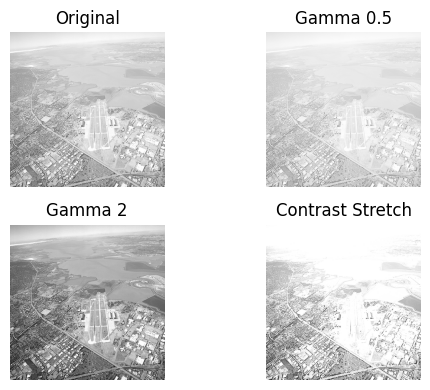

In [4]:
g05 = gamma_correction(runway, 0.5)
g2 = gamma_correction(runway, 2)
cs = contrast_stretch(runway)

titles = ["Original", "Gamma 0.5", "Gamma 2", "Contrast Stretch"]
images = [runway, g05, g2, cs]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()

Question 2

In [5]:
lab = cv2.cvtColor(highlights_and_shadows, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

l_gamma = gamma_correction(l, 0.8)
lab_new = cv2.merge([l_gamma, a, b])
result = cv2.cvtColor(lab_new, cv2.COLOR_LAB2BGR)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("LAB Gamma Result")
plt.axis('off')

error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function 'cv::impl::(anonymous namespace)::CvtHelper<cv::impl::(anonymous namespace)::Set<3, 4>, cv::impl::(anonymous namespace)::Set<3>, cv::impl::(anonymous namespace)::Set<0, 5>>::CvtHelper(InputArray, OutputArray, int) [VScn = cv::impl::(anonymous namespace)::Set<3, 4>, VDcn = cv::impl::(anonymous namespace)::Set<3>, VDepth = cv::impl::(anonymous namespace)::Set<0, 5>, sizePolicy = cv::impl::(anonymous namespace)::NONE]'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 1


In [ ]:
plt.hist(l.flatten(), bins=256, alpha=0.5, label='Original')
plt.hist(l_gamma.flatten(), bins=256, alpha=0.5, label='Gamma')
plt.legend()
plt.title("Histogram Comparison")

NameError: name 'l' is not defined